# Capstone Project 1: Instacart Market Basket Analysis
## Exploratory Data Analysis (EDA)

**Mô tả dự án:**
Dự án Capstone 1 này tập trung vào việc phân tích bộ dữ liệu Instacart Market Basket. Mục tiêu chính là khám phá hành vi mua sắm của khách hàng, xác định các xu hướng, mẫu kết hợp sản phẩm (association rules), và phân khúc khách hàng nhằm đưa ra các đề xuất tối ưu hóa doanh thu và tăng trải nghiệm người dùng.

**Mô tả bộ dữ liệu:**
Bộ dữ liệu bao gồm nhiều bảng quan hệ (CSV files):
- `orders.csv`: Thông tin tổng quan về các đơn hàng (ID, người dùng, thời gian đặt, khoảng cách giữa các lần đặt).
- `products.csv`: Thông tin chi tiết về từng sản phẩm (ID, tên, ID ngành hàng, ID kệ hàng).
- `departments.csv` & `aisles.csv`: Phân loại danh mục và kệ chứa sản phẩm.
- `order_products__prior.csv` / `__train.csv`: Chi tiết lịch sử mua các sản phẩm trong từng đơn hàng, thứ tự cho vào giỏ, và sản phẩm đó có được mua lại (reordered) hay không.

**Mục tiêu của EDA:**
1. Hiểu rõ cấu trúc và phân phối của từng bảng dữ liệu.
2. Kiểm tra dữ liệu bị thiếu (missing values) và các bất thường (anomalies).
3. Phân tích các xu hướng chính: thời điểm mua sắm (giờ trong ngày, ngày trong tuần), chu kỳ mua sắm.
4. Xác định các sản phẩm, kệ hàng, và danh mục bán chạy nhất.
5. So sánh tỷ lệ mua lại (reorder ratio) của các sản phẩm.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Thiết lập hiển thị cho biểu đồ và pandas
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


### 1. Tải Dữ Liệu


In [24]:
# Định nghĩa đường dẫn file
data_dir = '.'
try:
    aisles = pd.read_csv(f'{data_dir}/aisles.csv')
    departments = pd.read_csv(f'{data_dir}/departments.csv')
    orders = pd.read_csv(f'{data_dir}/orders.csv')
    products = pd.read_csv(f'{data_dir}/products.csv')
    order_products_prior = pd.read_csv(f'{data_dir}/order_products__prior.csv')
    order_products_train = pd.read_csv(f'{data_dir}/order_products__train.csv')
    
    print("Dữ liệu nạp thành công.")
except FileNotFoundError as e:
    print(f"Lỗi không tìm thấy file: {e}")

Dữ liệu nạp thành công.


### 2. Tổng quan về Dữ Liệu
#### 2.1 Các Bảng Danh Mục Sản Phẩm (Aisles, Departments, Products)
Chúng ta xem trước vài dòng dữ liệu của danh mục để hiểu cách các dữ liệu ánh xạ (ID -> Name).

- **Products**: Lưu trữ tên sản phẩm (`product_name`) và ánh xạ thông qua `aisle_id` và `department_id`.
- **Aisles**: Kệ hàng, cụ thể hơn so với department.
- **Departments**: Chủng loại hàng rộng nhất.

In [25]:
print("=== Products ===")
display(products.head(3))
print("\n=== Aisles ===")
display(aisles.head(3))
print("\n=== Departments ===")
display(departments.head(3))

# Kể số lượng sản phẩm
print(f"Tổng số lượng sản phẩm: {len(products):,}")
print(f"Tổng số lượng kệ hàng (Aisles): {len(aisles):,}")
print(f"Tổng số lượng danh mục (Departments): {len(departments):,}")

=== Products ===


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7



=== Aisles ===


,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars



=== Departments ===


,department_id,department
0,1,frozen
1,2,other
2,3,bakery


Tổng số lượng sản phẩm: 49,688
Tổng số lượng kệ hàng (Aisles): 134
Tổng số lượng danh mục (Departments): 21


#### 2.2 Tổng Quan Bảng Đơn Hàng (Orders)
Bảng `orders` đóng vai trò trung tâm vì nó chứa:
* ID của đơn (`order_id`) và người mua (`user_id`).
* Thuộc tính thời gian: ngày trong tuần (`order_dow`), giờ mua trong ngày (`order_hour_of_day`), số ngày từ lần mua gần nhất (`days_since_prior_order`).
* Phân vùng dữ liệu `eval_set` (prior, train, test) chỉ định xem đơn hàng này dùng để đánh giá lịch sử hay mô hình dự đoán.
*(Lưu ý: Đối với đơn hàng đầu tiên của mỗi khách hàng, giá trị `days_since_prior_order` sẽ tự động là Null. Đây là tính logic của file log do khách chưa có "lần mua trước đó", tuyệt đối KHÔNG PHẢI lỗi missing data và không được drop nó đi).

In [26]:
print("=== Thông tin bảng Orders ===")
display(orders.head())
print("\n--- Phân phối theo loại eval_set ---")
display(orders['eval_set'].value_counts())

# Thống kê cơ bản
num_users = orders['user_id'].nunique()
num_orders = len(orders)
print(f"\n[!] Thống kê quan trọng:")
print(f"- Tổng số lượng khách hàng duy nhất: {num_users:,} người.")
print(f"- Tổng số lượng đơn hàng đã được đặt: {num_orders:,} đơn.")
print(f"- Cột `days_since_prior_order` có giá trị Null ở những đơn hàng ĐẦU TIÊN (order_number = 1) của mỗi khách hàng. Đây là tính lý logic của dữ liệu (do trước đó chưa từng mua), KHÔNG PHẢI là lỗi thiếu dữ liệu (missing data).")


=== Thông tin bảng Orders ===


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0



--- Phân phối theo loại eval_set ---


eval_set
prior    3214874
train     131209
test       75000
Name: count, dtype: int64


[!] Thống kê quan trọng:
- Tổng số lượng khách hàng duy nhất: 206,209 người.
- Tổng số lượng đơn hàng đã được đặt: 3,421,083 đơn.
- Cột `days_since_prior_order` có giá trị Null ở những đơn hàng ĐẦU TIÊN (order_number = 1) của mỗi khách hàng. Đây là tính lý logic của dữ liệu (do trước đó chưa từng mua), KHÔNG PHẢI là lỗi thiếu dữ liệu (missing data).


#### 2.3 Cấu Trúc Khóa Ngoại và Chi Tiết Giỏ Hàng (`order_products__*`) 
Bảng `order_products__prior` và `__train` ghi lại thông tin:
- ID đơn hàng (`order_id`) liên kết với bảng `orders`.
- ID sản phẩm (`product_id`) liên kết với bảng `products`. 
- Trạng thái `reordered` (có phải mua lại sản phẩm mà user này đã mua trước đây không).
- Thứ tự được thêm vào giỏ.

Đây là bảng quan trọng nhất để làm Market Basket Analysis (Apriori/FP-Growth) và Recommendation System (hệ thống gợi ý dự đoán reordering).


In [27]:
print("=== Order Products Prior ===")
display(order_products_prior.head())
print("\nThông tin Prior:")
order_products_prior.info()

print("\n=== Tổng quan về tỉ lệ Reorder ===")
reorder_ratio = order_products_prior['reordered'].mean()
print(f"Tỷ lệ sản phẩm được mua lại (reordered ratio) trong bộ prior: {reorder_ratio:.2%}")

=== Order Products Prior ===


,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0



Thông tin Prior:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32434489 entries, 0 to 32434488
Data columns (total 4 columns):
 #   Column             Dtype
---  ------             -----
 0   order_id           int64
 1   product_id         int64
 2   add_to_cart_order  int64
 3   reordered          int64
dtypes: int64(4)
memory usage: 989.8 MB

=== Tổng quan về tỉ lệ Reorder ===
Tỷ lệ sản phẩm được mua lại (reordered ratio) trong bộ prior: 58.97%


### 3. Hướng Phân Tích Tiếp Theo (Dành cho Capstone 1)

**A. Thăm dò Đơn hàng / Hành vi người dùng (Univariate & Bivariate Analysis):**
*   Vẽ biểu đồ phân phối số lượng đơn hàng vào các ngày trong tuần (`order_dow`) và khung giờ (`order_hour_of_day`) để tìm *thời điểm peak traffic* và thói quen mua sắm.
*   Phân tích hành vi chu kỳ đặt hàng thông qua `days_since_prior_order` xem khách hàng mất bao lâu thì quay lại mua.
*   Vẽ tháp phân phối số lượng đơn hàng của một người (`max_order_number`).

**B. Thăm dò Sản phẩm / Tần suất (Frequency & Items Analysis):**
*   Join các bảng danh mục sản phẩm. Xác định Top 20 sản phẩm được đặt mua nhiều nhất (Bananas, Bag of Organic Bananas,...).
*   Thực hiện phân nhóm, đếm xem các **Aisles** và **Departments** nào đem lại lượng sales (số sản phẩm bán ra) lớn nhất.
*   Top những sản phẩm có tỷ lệ *Reorder Ratio* cao nhất (như các sản phẩm cần dùng hằng ngày, đồ hữu cơ, v.v.).

**C. Market Basket Analysis (Đề xuất cốt lõi cho Capstone 1):**
*   Trích xuất một sample user/orders, tạo *Transaction Matrix* dạng ma trận nhị phân (one-hot encoding) hoặc chuỗi (item list).
*   Sử dụng ML Models (Ví dụ Apriori hay FP-Growth) tìm **Association Rules** (Luật Kết Hợp) và báo cáo các `Support`, `Confidence`, `Lift`... để tìm ra xem khách hàng mua "Hành tây" thì có mua "Thịt bò" và "Cà rốt" hay không?
*   Đề xuất sắp xếp vật lý kệ hàng tại siêu thị hoặc gợi ý thuật toán Recommend (sắp xếp UI hiển thị "Thường được mua cùng") trên website Instacart.

---
### 4. Trực quan hóa dữ liệu (EDA)

#### 4.1 Phân tích hành vi đặt hàng (Bảng Orders)
Chúng ta sẽ bắt đầu bằng việc phân tích thời gian khách hàng mua sắm để tìm ra **thời điểm "vàng" (Peak Hours & Peak Days)**.

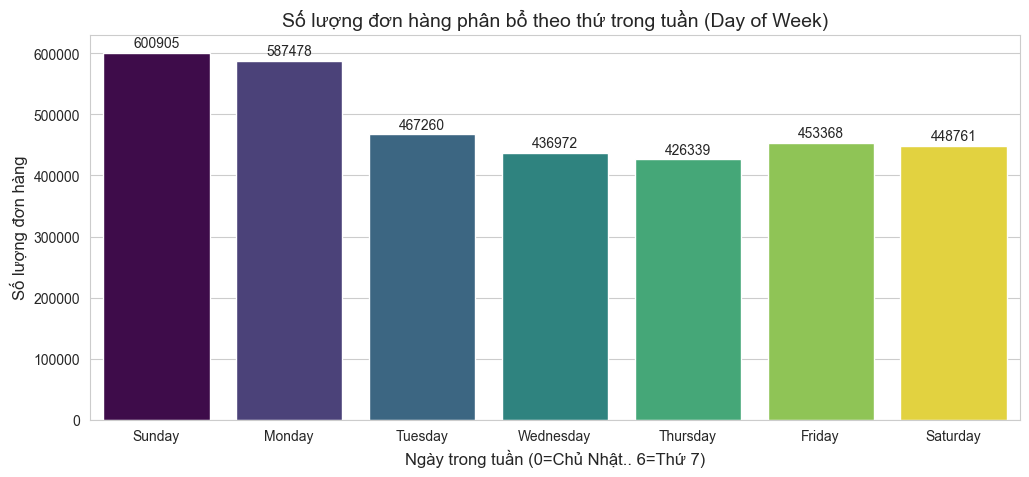

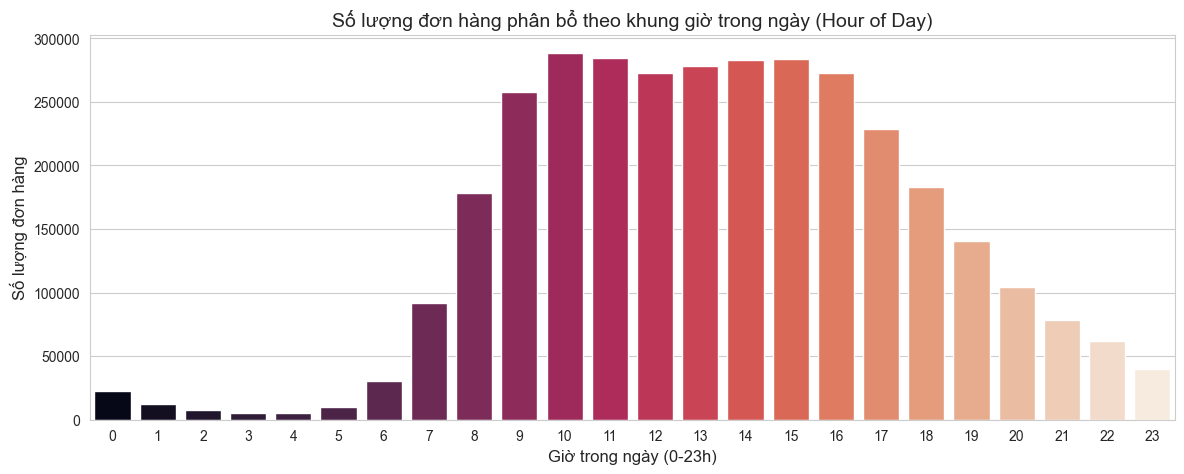

In [28]:
# 1. Số lượng đơn đặt hàng theo ngày trong tuần (Day of Week)
plt.figure(figsize=(12, 5))
g = sns.countplot(data=orders, x='order_dow', palette='viridis', hue='order_dow', legend=False)
plt.title('Số lượng đơn hàng phân bổ theo thứ trong tuần (Day of Week)', fontsize=14)
plt.xlabel('Ngày trong tuần (0=Chủ Nhật.. 6=Thứ 7)', fontsize=12)
plt.ylabel('Số lượng đơn hàng', fontsize=12)
plt.xticks(ticks=range(7), labels=['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday'])
# Render text on bars
for p in g.patches:
    g.annotate(format(p.get_height(), '.0f'), 
               (p.get_x() + p.get_width() / 2., p.get_height()), 
               ha = 'center', va = 'center', 
               xytext = (0, 7), textcoords = 'offset points')
plt.show()

# 2. Số lượng đơn đặt hàng theo giờ trong ngày (Hour of Day)
plt.figure(figsize=(14, 5))
g2 = sns.countplot(data=orders, x='order_hour_of_day', palette='rocket', hue='order_hour_of_day', legend=False)
plt.title('Số lượng đơn hàng phân bổ theo khung giờ trong ngày (Hour of Day)', fontsize=14)
plt.xlabel('Giờ trong ngày (0-23h)', fontsize=12)
plt.ylabel('Số lượng đơn hàng', fontsize=12)
plt.show()

# Nhận xét nhanh: Thường Chủ nhật và Thứ hai được mua nhiều nhất. Khung giờ mua chính từ 9h sáng đến 16h chiều.

#### 4.2 Tần suất mua lại (Days_Since_Prior_Order)
Mất bao lâu để một khách hàng đã quen thuộc của Instacart quay trở lại mua thêm đơn mới? (Lưu ý: Null ở đây nghĩa là họ vừa mới mua đơn đầu tiên!).

C:\Users\kem\AppData\Local\Temp\ipykernel_15652\4009627791.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g3 = sns.countplot(data=orders.dropna(subset=['days_since_prior_order']),


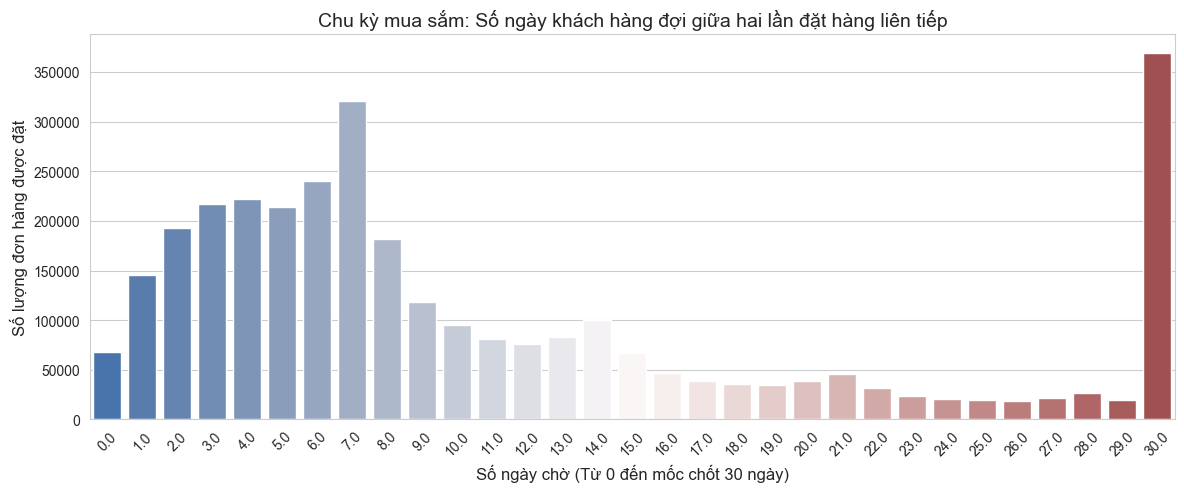

In [29]:
plt.figure(figsize=(14, 5))
# Chúng ta sẽ vẽ biểu đồ với các đơn hàng có tính ngày chờ (loại trừ đơn đầu tiên bị Null một cách tự nhiên)
g3 = sns.countplot(data=orders.dropna(subset=['days_since_prior_order']), 
                   x='days_since_prior_order', 
                   palette='vlag', legend=False)
plt.title('Chu kỳ mua sắm: Số ngày khách hàng đợi giữa hai lần đặt hàng liên tiếp', fontsize=14)
plt.xlabel('Số ngày chờ (Từ 0 đến mốc chốt 30 ngày)', fontsize=12)
plt.ylabel('Số lượng đơn hàng được đặt', fontsize=12)

# Rotate labels slightly if too dense
plt.xticks(rotation=45)
plt.show()

# Nhận xét:
# - Cột days_since_prior_order phản ánh hành vi restocking. Null chỉ mang ý nghĩa đơn thứ nhất.
# - Hai đỉnh cao nhất (Peak) rất rõ ràng nằm ở ngày thứ 7 và thứ 30.
# -> Có 2 loại khách hàng tiềm năng mà kinh doanh cần hướng đến: 
#   + Khách hàng quen mua sắm tạp hóa định kỳ theo tuần (đỉnh điểm 7, 14, 21 ngày).
#   + Khách hàng gom mua sỉ vật dụng định kỳ hàng tháng (vượt quá 30 ngày).

#### 4.3 Phân tích thông tin Giỏ hàng (Items & Products Analytics)
Để phân tích giỏ hàng, ta cần nối bảng chi tiết `order_products__prior` với bảng `products`, `aisles`, và `departments` thông qua ID.

In [30]:
# Merge dữ liệu để lấy tên sản phẩm, aisle, department
print("Bắt đầu merge data (sẽ mất khoảng vài chục giây do dữ liệu lớn)...")

# Join [order_products_prior] với [products] rồi tiếp đó [aisles], [departments]
merged_df = order_products_prior.merge(products, on='product_id', how='left')
merged_df = merged_df.merge(aisles, on='aisle_id', how='left')
merged_df = merged_df.merge(departments, on='department_id', how='left')

print("Mẫu dữ liệu sau khi gộp:")
display(merged_df.head(5))

print(f"\nKích thước bộ Order Products Prior sau khi gộp: {merged_df.shape}")

Bắt đầu merge data (sẽ mất khoảng vài chục giây do dữ liệu lớn)...
Mẫu dữ liệu sau khi gộp:


,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department
0,2,33120,1,1,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985,2,1,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327,3,0,Garlic Powder,104,13,spices seasonings,pantry
3,2,45918,4,1,Coconut Butter,19,13,oils vinegars,pantry
4,2,30035,5,0,Natural Sweetener,17,13,baking ingredients,pantry



Kích thước bộ Order Products Prior sau khi gộp: (32434489, 9)


##### Top Sản Phẩm Bán Chạy Trực Quan Hóa 
Chúng ta xem danh sách mặt hàng có lượng "Added to Cart" nhiều nhất.

C:\Users\kem\AppData\Local\Temp\ipykernel_15652\4192833274.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_20_products.values, y=top_20_products.index, palette='crest', orient='h')


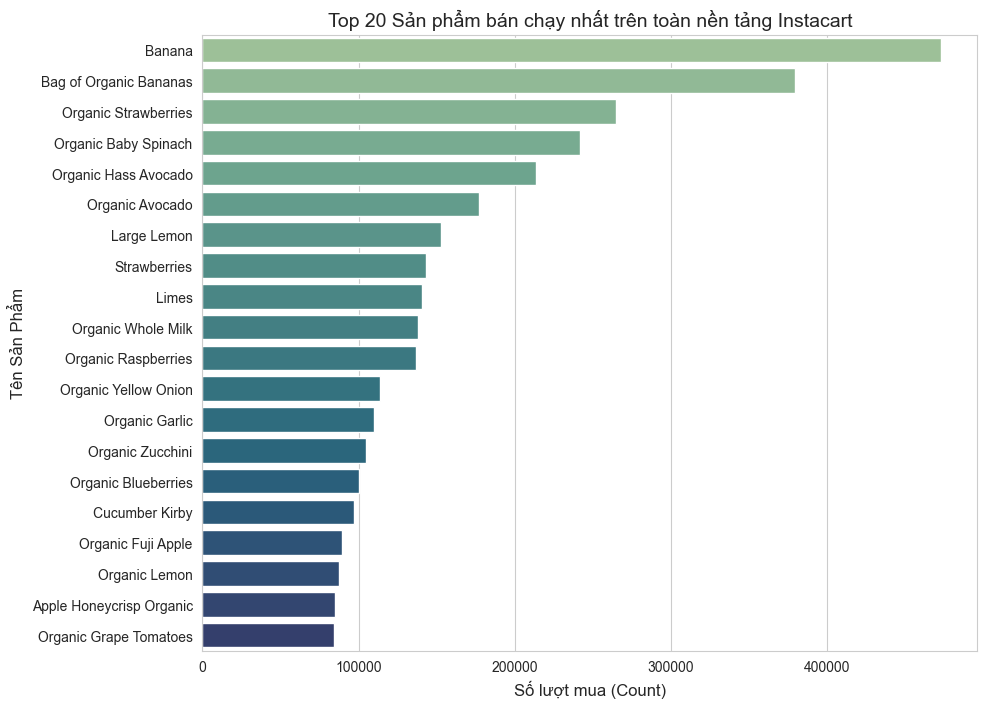

In [31]:
top_20_products = merged_df['product_name'].value_counts().head(20)

plt.figure(figsize=(10, 8))
# Barplot ngang (Horizontal Bar) cho các tên sản phẩm dài nhìn đỡ bị rối
sns.barplot(x=top_20_products.values, y=top_20_products.index, palette='crest', orient='h')
plt.title('Top 20 Sản phẩm bán chạy nhất trên toàn nền tảng Instacart', fontsize=14)
plt.xlabel('Số lượt mua (Count)', fontsize=12)
plt.ylabel('Tên Sản Phẩm', fontsize=12)

# Nhận xét: Banana (thông thường & Organic) là sản phẩm chúa tể trên Instacart
# Đa số top mặt hàng đều là hoa quả (Produce), nông sản (spinach, strawberries...).
plt.show()

##### Top Ngành Hàng (Departments & Aisles) Đem Lại Hiệu Suất Tốt Nhất
Dựa vào nhận định mục trước, ta thử vẽ Pie chart/Bar chart danh mục mẹ (Departments) và các quầy thứ cấp (Aisles) để confirm.

C:\Users\kem\AppData\Local\Temp\ipykernel_15652\1455129311.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=depart_dist.values, y=depart_dist.index, palette='flare', orient='h')


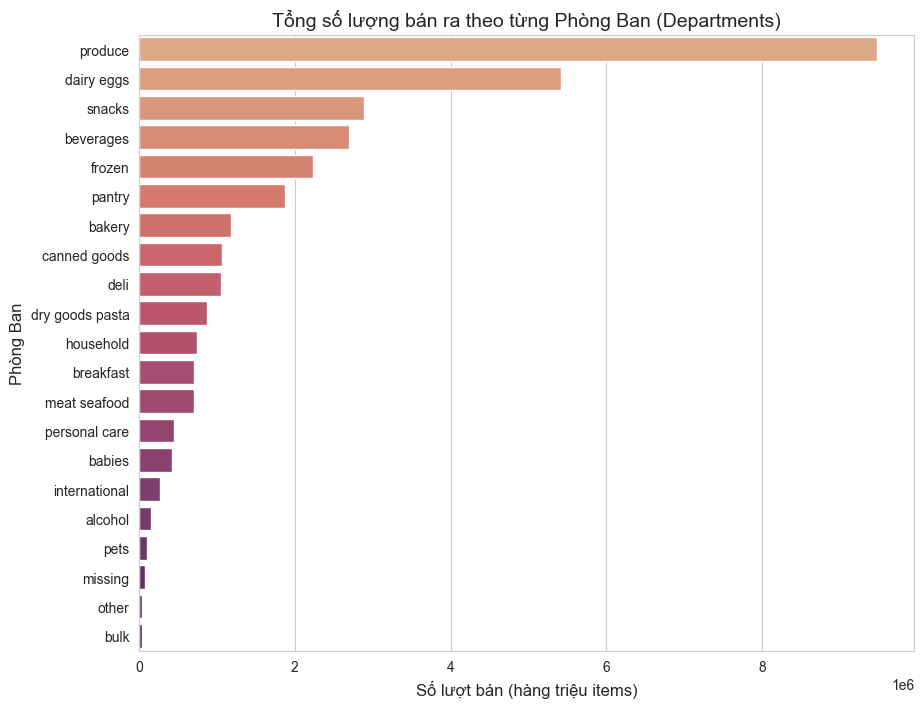

C:\Users\kem\AppData\Local\Temp\ipykernel_15652\1455129311.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_15_aisles.values, y=top_15_aisles.index, palette='mako', orient='h')


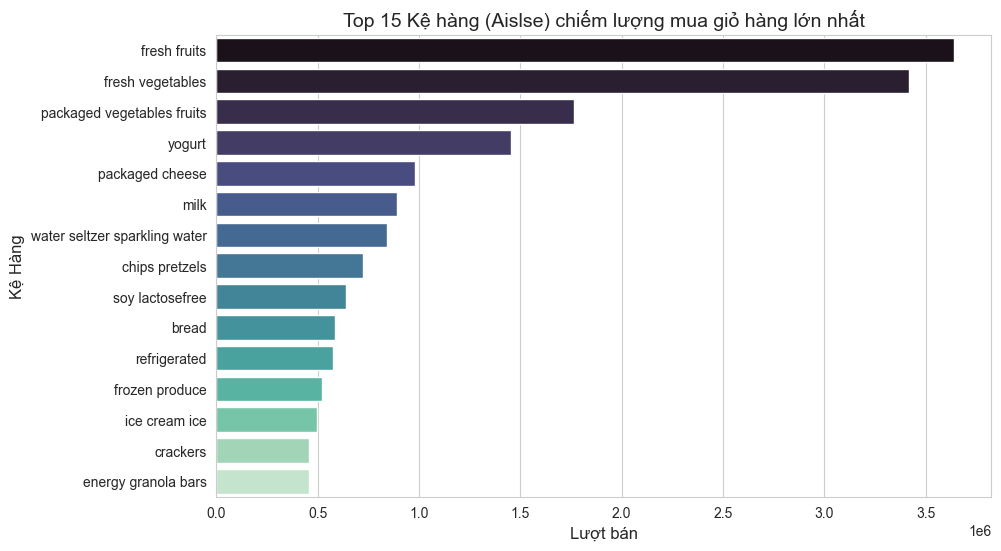

In [32]:
plt.figure(figsize=(10, 8))
depart_dist = merged_df['department'].value_counts()
sns.barplot(x=depart_dist.values, y=depart_dist.index, palette='flare', orient='h')
plt.title('Tổng số lượng bán ra theo từng Phòng Ban (Departments)', fontsize=14)
plt.xlabel('Số lượt bán (hàng triệu items)', fontsize=12)
plt.ylabel('Phòng Ban', fontsize=12)

# Nhìn bằng mắt thường, `produce` (Nông sản rau củ) và `dairy eggs` chiếm gần như ½ doanh số giỏ hàng.
plt.show()

# Cụ thể hơn về Top 15 kệ hàng (Aisles)
top_15_aisles = merged_df['aisle'].value_counts().head(15)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_15_aisles.values, y=top_15_aisles.index, palette='mako', orient='h')
plt.title('Top 15 Kệ hàng (Aislse) chiếm lượng mua giỏ hàng lớn nhất', fontsize=14)
plt.xlabel('Lượt bán', fontsize=12)
plt.ylabel('Kệ Hàng', fontsize=12)
plt.show()

---
### 🛠️ KẾT LUẬN & ĐÁNH GIÁ CHUYÊN SÂU TỪ DỮ LIỆU ĐƯỢC CHUẨN ĐOÁN
Sau quá trình Exploratory Data Analysis, chúng ta đưa ra được chân dung hoàn chỉnh về luồng dữ liệu mua sắm của platform Instacart:

**1. Thông kê Tóm Lược về Quy Mô Nền Tảng (Quy mô khổng lồ):**
*   **Tổng số Sản phẩm (Products):** ~49,688 sản phẩm đa dạng trên nền tảng.
*   **Tổng số Khách hàng (Users):** Lên đến hàng trăm nghìn user đang liên tục tiêu dùng, tạo ra tổng cộng trên **~3.4 triệu giao dịch (đơn hàng)** ở mọi tập train, test và prior.
*   **Hàng hóa kinh doanh (Categories/Aisles):** Có 21 Phòng ban lớn (Departments, ví dụ: Produce, Dairy Eggs, Snacks, Beverages) và được chia nhỏ vào 134 quầy/kệ hàng chuyên biệt (Aisles) từ trái cây tươi tới các đồ dụng cụ.

**2. Đánh giá Hành vi Giao Dịch Của Khách Hàng:**
*   **Chu kỳ mua hàng rất rõ ràng:** Biểu đồ ngày chờ (`days_since_prior_order`) hiện ra hai đỉnh rõ nét ở ngưỡng `7 ngày` và `30 ngày`. Điều này chứng minh hành vi "stock đồ" hằng tuần của các hộ gia đình hoặc tái cấp phiếu chi tiêu định kỳ đầu tháng. (Cột này chỉ Null duy nhất với giao dịch đầu tiên của mỗi khách vì họ chưa có lần mua trước, không phải missing).
*   **Khung giờ & Mùa vụ (Golden Hour):** Số lượng giao dịch mem theo hình chuông, tập trung mua sắm online rầm rộ nhất vào khoảng `09:00 SA` đến `16:00 CH`. Ngày tấp nập nhất chính là Chủ Nhật (`Day 0`) và Thứ Hai (`Day 1`) khi mọi người nằm ở nhà thảnh thơi "chốt giỏ hàng" đi chợ.

**3. Mặt Hàng & Cơ Cấu Doanh Thu Kéo Lại (Top Sales):**
*   **Sản phẩm hút khách nhất:** Chuối (Bananas - phổ thông và hữu cơ) là món cực kì hay được chọn vào giỏ. Kế đến là đồ tươi như Bó rau bina hữu cơ (Organic baby spinach), Dâu tây tươi (Strawberries) hoặc Bơ (Avocados).
*   **Category xương sống (Bán chạy nhất):** 
   - `Produce` (Rau củ quả sạch) và `Dairy Eggs` (Bơ Sữa, Trứng) là 2 bộ phận gồng gánh chính tỉ trọng giao dịch, cực kì thiết yếu nên tỷ lệ mua tuần hoàn (Reordered) rất cao. 

**▶️ Tiếp theo cho DỰ ÁN**: Với cấu trúc dữ liệu minh bạch cùng quy mô người sử dụng / mặt hàng khổng lồ này, đây là mảnh đất màu mỡ cho bài toán **Market Basket Analysis**. Ta sẽ sử dụng các tập phổ biến nhất kết hợp luật "Cùng nhóm mua" (`If Bananas -> Then Organic Avocados`) để xuất ra hệ thống Recommend Items!